# Level-1

# Task 1: Data Preprocessing

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load dataset
df = pd.read_csv("C:\\Drivers\\1) iris.csv")

# Show dataset
print(df.head())
print(df.info())

# 1. Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# 2. Encode categorical column (species)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# 3. Split Features & Target
X = df.drop("species", axis=1)
y = df["species"]

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing Done")

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
Preprocessing Done


# Task 2: KNN Classifier

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Model (try different K values)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Comparing Different K values

In [17]:
for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"K={k}, Accuracy={accuracy_score(y_test, pred)}")

K=1, Accuracy=1.0
K=3, Accuracy=1.0
K=5, Accuracy=1.0
K=7, Accuracy=1.0


# Graph

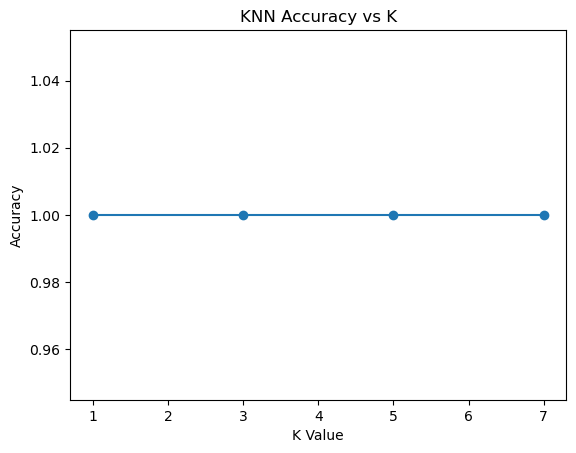

In [18]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

# Level-2

# Task 1: Logistic Regression (Churn Dataset)

In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt

# Load datasets
train_df = pd.read_csv("C:\Drivers\churn-bigml-80.csv")
test_df = pd.read_csv("C:\Drivers\churn-bigml-20.csv")

# Show data
print(train_df.head())

# Convert categorical to numeric
le = LabelEncoder()
for col in train_df.select_dtypes(include='object'):
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Split features & target
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

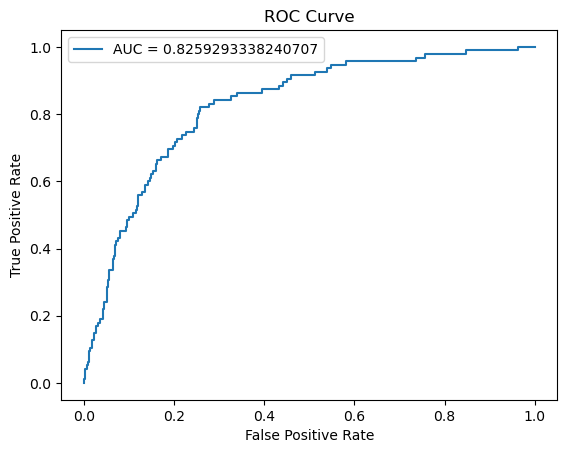

In [20]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Task 2: Decision Tree (Iris Dataset)

Accuracy: 0.9333333333333333
F1 Score: 0.9273809523809523


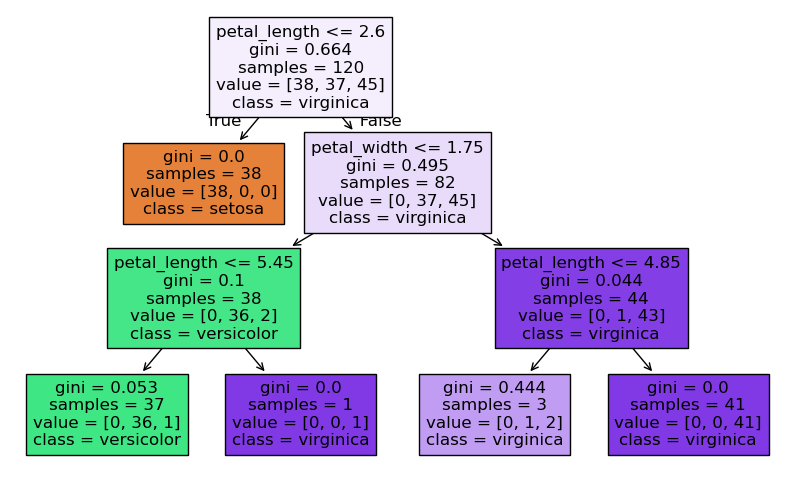

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("C:\\Drivers\\1) iris.csv")

# Split
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model with pruning (max_depth)
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

# Tree Visualization
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=df['species'].unique(), filled=True)
plt.show()

# Level-3

# Task 1: Random Forest Classifier

In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
train_df = pd.read_csv("C:\Drivers\churn-bigml-80.csv")
test_df = pd.read_csv("C:\Drivers\churn-bigml-20.csv")

# Encode categorical columns
le = LabelEncoder()
for col in train_df.select_dtypes(include='object'):
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# Split
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest Model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

       False       0.92      1.00      0.95       572
        True       0.98      0.44      0.61        95

    accuracy                           0.92       667
   macro avg       0.95      0.72      0.78       667
weighted avg       0.92      0.92      0.91       667



In [23]:
import pandas as pd

# Feature importance
importance = pd.Series(rf.feature_importances_, index=train_df.drop("Churn", axis=1).columns)

print("\nFeature Importance:\n")
print(importance.sort_values(ascending=False))


Feature Importance:

Total day minutes         0.183672
Total day charge          0.171896
Customer service calls    0.145371
International plan        0.126290
Total eve charge          0.058344
Total eve minutes         0.045936
Total intl calls          0.045574
Total intl minutes        0.044156
Number vmail messages     0.030828
Total intl charge         0.026457
Voice mail plan           0.026275
Total night charge        0.021309
Total night minutes       0.016514
Total day calls           0.015542
Total night calls         0.012281
Account length            0.012048
Total eve calls           0.009257
State                     0.006222
Area code                 0.002030
dtype: float64


# Task 2: Support Vector Machine (SVM)

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)
pred_linear = svm_linear.predict(X_test)

# RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
pred_rbf = svm_rbf.predict(X_test)

# Evaluation
print("---- Linear Kernel ----")
print("Accuracy:", accuracy_score(y_test, pred_linear))
print("Precision:", precision_score(y_test, pred_linear))
print("Recall:", recall_score(y_test, pred_linear))

print("\n---- RBF Kernel ----")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print("Precision:", precision_score(y_test, pred_rbf))
print("Recall:", recall_score(y_test, pred_rbf))

---- Linear Kernel ----
Accuracy: 0.8575712143928036
Precision: 0.0
Recall: 0.0

---- RBF Kernel ----
Accuracy: 0.9190404797601199
Precision: 0.8867924528301887
Recall: 0.49473684210526314


C:\Users\tanya\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
